In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

Dữ liệu gốc: (160, 908) (910 đặc trưng)
--- ĐANG LỌC BỎ NHIỄU (FEATURE SELECTION) ---
=> Đã giảm xuống còn: 313 đặc trưng tinh túy nhất.

--- KẾT QUẢ 5-FOLD CROSS VALIDATION (CÓ LỌC) ---
MÔ HÌNH                   | ACCURACY (TB)   | ĐỘ ỔN ĐỊNH (+/-)
-----------------------------------------------------------------
Logistic Regression       | 78.75%          | +/- 2.34%
KNN (k=5)                 | 69.38%          | +/- 9.96%
SVM (RBF)                 | 77.50%          | +/- 4.59%
SVM (Linear)              | 73.75%          | +/- 3.19%
Random Forest             | 76.25%          | +/- 6.43%
Gradient Boosting         | 76.25%          | +/- 4.24%
Extra Trees               | 76.25%          | +/- 6.73%
AdaBoost                  | 72.50%          | +/- 3.06%
XGBoost                   | 74.38%          | +/- 3.64%
LightGBM                  | 73.75%          | +/- 5.80%
CatBoost                  | 76.25%          | +/- 5.45%
Neural Net (MLP)          | 80.00%          | +/- 4.24%
LDA         

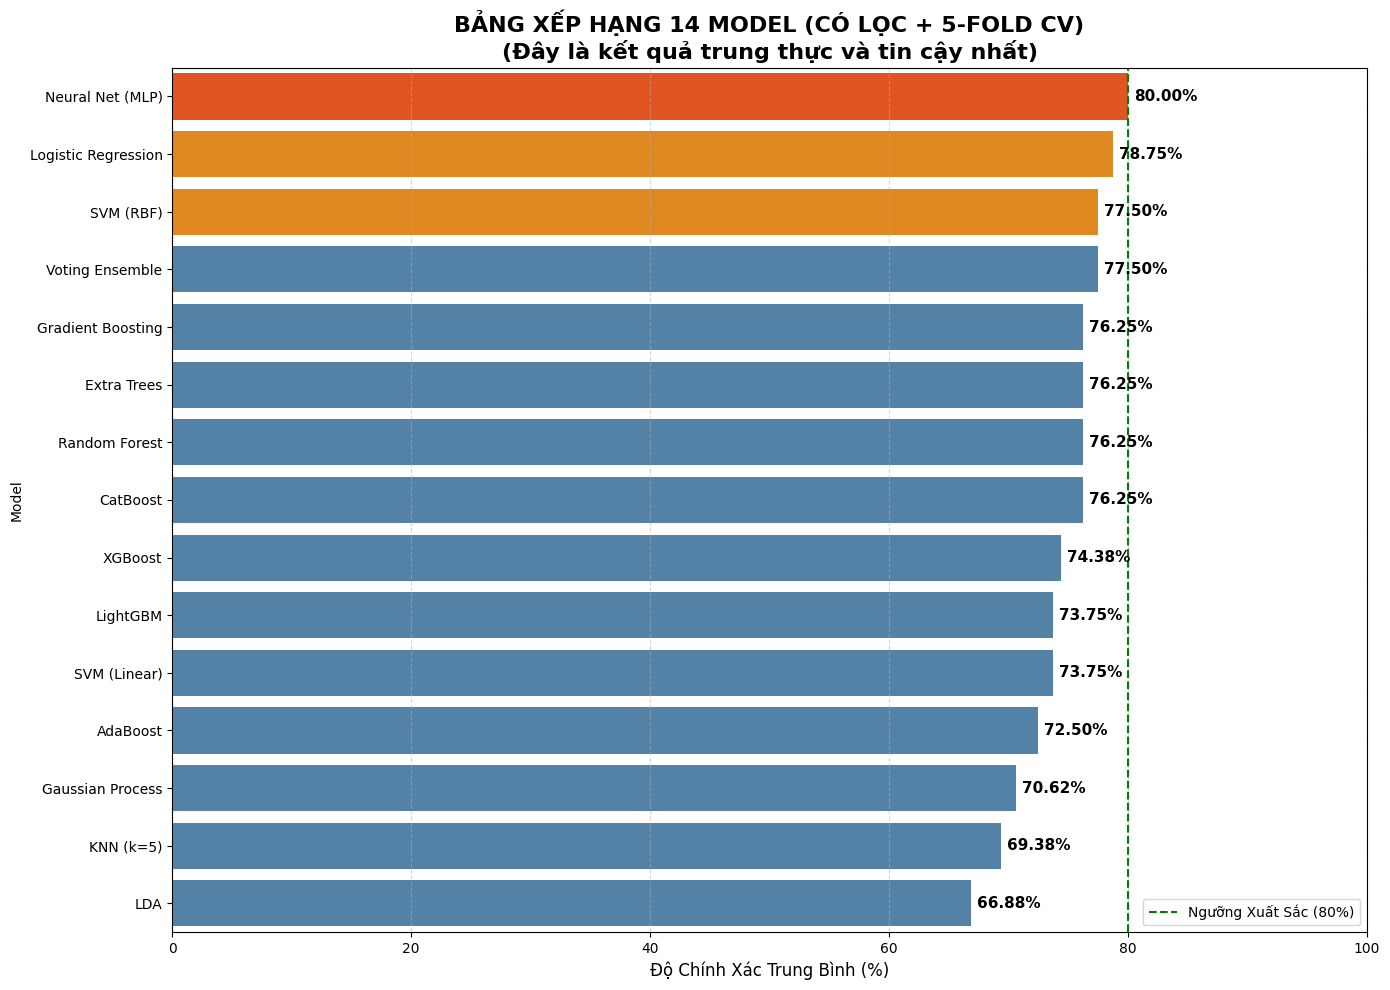


🏆 NHÀ VÔ ĐỊCH CHUNG CUỘC: Neural Net (MLP) (80.00%)


In [ ]:
# =============================================================================
# BENCHMARK TOÀN DIỆN: 14 MÔ HÌNH + FEATURE SELECTION + 5-FOLD CV
# =============================================================================



# --- 1. CATBOOST WRAPPER (Để chạy êm ru không lỗi) ---
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=200, verbose=0, random_state=42):
        self.iterations = iterations
        self.verbose = verbose
        self.random_state = random_state
        self.model = None
    def fit(self, X, y):
        self.model = CatBoostClassifier(iterations=self.iterations, verbose=self.verbose, 
                                        random_state=self.random_state, allow_writing_files=False)
        self.model.fit(X, y)
        self.classes_ = self.model.classes_ 
        return self
    def predict(self, X): return self.model.predict(X)
    def predict_proba(self, X): return self.model.predict_proba(X)

# --- 2. ĐỌC DỮ LIỆU ---
file_path = 'eye_tracking_features_k30_graph.csv'
df = pd.read_csv(file_path)

X = df.drop(columns=['label', 'numeric_id'])
y = df['label']

print(f"Dữ liệu gốc: {X.shape} (910 đặc trưng)")

# --- 3. BƯỚC QUAN TRỌNG: LỌC ĐẶC TRƯNG (FEATURE SELECTION) ---
print("--- ĐANG LỌC BỎ NHIỄU (FEATURE SELECTION) ---")
# Dùng Random Forest để chọn ra các đặc trưng tốt nhất
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="mean")
X_selected = selector.fit_transform(X, y)

print(f"=> Đã giảm xuống còn: {X_selected.shape[1]} đặc trưng tinh túy nhất.")

# --- 4. CHUẨN HÓA DỮ LIỆU ---
# Vì ta chạy đua công bằng cho cả SVM, KNN nên bắt buộc phải Scale
scaler = StandardScaler()
X_final = scaler.fit_transform(X_selected)

# --- 5. KHỞI TẠO 14 CHIẾN BINH ---
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)),
    ('SVM (RBF)', SVC(kernel='rbf', probability=True)),
    ('SVM (Linear)', SVC(kernel='linear', probability=True)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ('Extra Trees', ExtraTreesClassifier(n_estimators=200, random_state=42)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(n_estimators=200, eval_metric='logloss', use_label_encoder=False, random_state=42)),
    ('LightGBM', LGBMClassifier(n_estimators=200, verbose=-1, random_state=42)),
    ('CatBoost', CatBoostWrapper(iterations=200, verbose=0, random_state=42)),
    ('Neural Net (MLP)', MLPClassifier(max_iter=1000, random_state=42)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('Gaussian Process', GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42))
]

# Voting Ensemble
voting_clf = VotingClassifier(estimators=[
    ('gb', models[5][1]), ('et', models[6][1]), ('svm', models[2][1])], voting='soft')
models.append(('Voting Ensemble', voting_clf))

# --- 6. CHẠY 5-FOLD CROSS VALIDATION CHO TẤT CẢ ---
print("\n--- KẾT QUẢ 5-FOLD CROSS VALIDATION (CÓ LỌC) ---")
print(f"{'MÔ HÌNH':<25} | {'ACCURACY (TB)':<15} | {'ĐỘ ỔN ĐỊNH (+/-)'}")
print("-" * 65)

results = []
names = []
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models:
    try:
        # Chạy kiểm thử chéo
        cv_scores = cross_val_score(model, X_final, y, cv=kfold, scoring='accuracy')
        
        acc_mean = cv_scores.mean() * 100
        acc_std = cv_scores.std() * 100
        
        results.append(acc_mean)
        names.append(name)
        
        print(f"{name:<25} | {acc_mean:.2f}%          | +/- {acc_std:.2f}%")
    except Exception as e:
        print(f"{name:<25} | LỖI: {e}")
        results.append(0)
        names.append(name)

# --- 7. VẼ BIỂU ĐỒ ---
df_res = pd.DataFrame({'Model': names, 'Accuracy': results})
df_res = df_res.sort_values(by='Accuracy', ascending=False)
df_res = df_res[df_res['Accuracy'] > 0]

plt.figure(figsize=(14, 10))
# Tô màu: Top 1 Đỏ, Top 2-3 Cam, còn lại Xanh
colors = ['#FF4500' if i==0 else '#FF8C00' if i<3 else '#4682B4' for i in range(len(df_res))]

ax = sns.barplot(x='Accuracy', y='Model', data=df_res, palette=colors)

for i, v in enumerate(df_res['Accuracy']):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold', fontsize=11)

plt.title('BẢNG XẾP HẠNG 14 MODEL (CÓ LỌC + 5-FOLD CV)\n(Đây là kết quả trung thực và tin cậy nhất)', fontsize=16, fontweight='bold')
plt.xlabel('Độ Chính Xác Trung Bình (%)', fontsize=12)
plt.xlim(0, 100)
plt.axvline(x=80, color='green', linestyle='--', label='Ngưỡng Xuất Sắc (80%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

if not df_res.empty:
    print(f"\n🏆 NHÀ VÔ ĐỊCH CHUNG CUỘC: {df_res.iloc[0]['Model']} ({df_res.iloc[0]['Accuracy']:.2f}%)")

Dữ liệu gốc: (160, 908) (900+ đặc trưng)

--- BƯỚC 1: LỌC NHIỄU (SelectFromModel) ---
=> Đã giảm xuống còn: 313 đặc trưng tinh túy nhất.

--- BƯỚC 2: CHUẨN HÓA DỮ LIỆU (Scaling) ---

--- BẮT ĐẦU CHẠY 5-FOLD CHI TIẾT ---
Fold  | Accuracy   | F1-Score   | AUC       
---------------------------------------------
1     | 75.00%     | 0.7647     | 0.8320
2     | 81.25%     | 0.7692     | 0.8516
3     | 87.50%     | 0.8750     | 0.8945
4     | 78.12%     | 0.7879     | 0.8672
5     | 78.12%     | 0.7407     | 0.8281


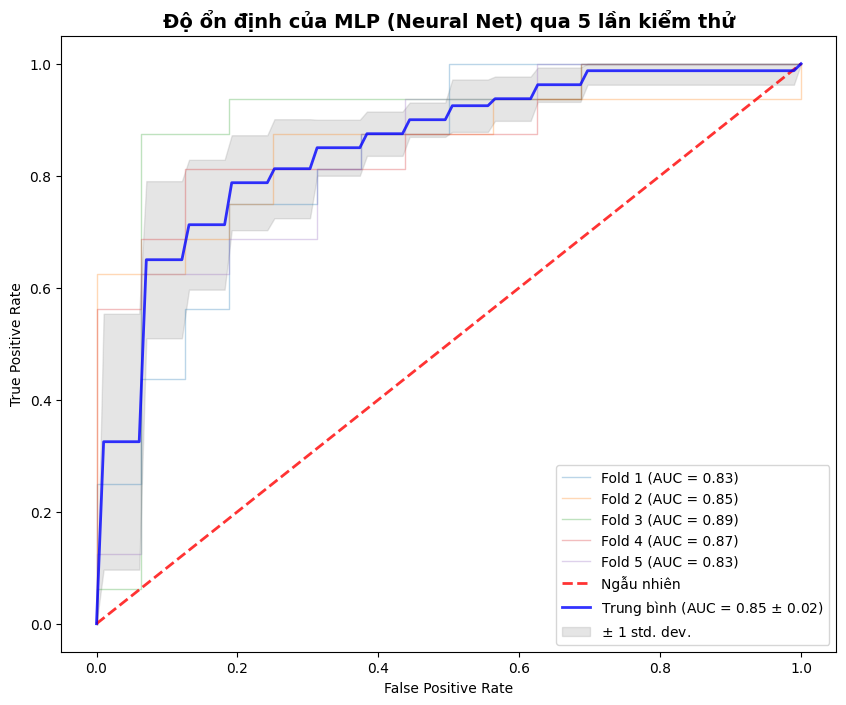


🏆 KẾT QUẢ CUỐI CÙNG (NEURAL NETWORK MLP)
Độ chính xác trung bình: 80.00% (+/- 4.24%)
AUC trung bình:          0.8521


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc, f1_score
import warnings

warnings.filterwarnings("ignore")

file_path = 'eye_tracking_features_k30_graph.csv'
df = pd.read_csv(file_path)

X = df.drop(columns=['label', 'numeric_id'])
y = df['label']

print(f"Dữ liệu gốc: {X.shape} (900+ đặc trưng)")
print("\n--- BƯỚC 1: LỌC NHIỄU (SelectFromModel) ---")
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="mean")
X_selected = selector.fit_transform(X, y)
print(f"=> Đã giảm xuống còn: {X_selected.shape[1]} đặc trưng tinh túy nhất.")

# BƯỚC B: CHUẨN HÓA (STANDARD SCALER)
# Mạng Neron bắt buộc phải có bước này mới hội tụ được
print("\n--- BƯỚC 2: CHUẨN HÓA DỮ LIỆU (Scaling) ---")
scaler = StandardScaler()
X_final = scaler.fit_transform(X_selected)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cấu hình MLP y hệt trong danh sách models cũ
# ('Neural Net (MLP)', MLPClassifier(max_iter=1000, random_state=42))
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Biến lưu kết quả để vẽ
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
accuracies = []
f1_scores = []

plt.figure(figsize=(10, 8))

print("\n--- BẮT ĐẦU CHẠY 5-FOLD CHI TIẾT ---")
print(f"{'Fold':<5} | {'Accuracy':<10} | {'F1-Score':<10} | {'AUC':<10}")
print("-" * 45)

for i, (train_idx, test_idx) in enumerate(cv.split(X_final, y)):
    # Chia dữ liệu (Dùng X_final đã qua xử lý)
    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Huấn luyện
    mlp.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = mlp.predict(X_test)
    y_prob = mlp.predict_proba(X_test)[:, 1]
    
    # Tính chỉ số
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Lưu lại
    accuracies.append(acc)
    f1_scores.append(f1)
    aucs.append(roc_auc)
    
    # Vẽ đường ROC mờ cho fold này
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.2f})')
    
    # Nội suy để tính trung bình
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    print(f"{i+1:<5} | {acc*100:.2f}%     | {f1:.4f}     | {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Ngẫu nhiên', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vẽ đường trung bình
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Trung bình (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})', lw=2, alpha=.8)

# Vẽ vùng sai số (Standard Deviation)
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Độ ổn định của MLP (Neural Net) qua 5 lần kiểm thử', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

# IN KẾT QUẢ TỔNG HỢP
print("\n" + "="*40)
print("🏆 KẾT QUẢ CUỐI CÙNG (NEURAL NETWORK MLP)")
print("="*40)
print(f"Độ chính xác trung bình: {np.mean(accuracies)*100:.2f}% (+/- {np.std(accuracies)*100:.2f}%)")
print(f"AUC trung bình:          {mean_auc:.4f}")
print("="*40)